# CTD data starter code

In [156]:
#!pip install --upgrade pip
#!pip install gsw


In [157]:
import gsw  # TEOS-10 Gibbs SeaWater toolbox
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Read in the CSV depth series data.

In [158]:
WATER_QUALITY_FILE_PATH = 'your path here'  # e.g. './data/EIMContinuousDepthSeriesData_2024Apr08_229519.csv'
ctd_all_data = pd.read_csv('C:\\Users\\Alex Eagan\\Downloads\\ajeagan00554\\EIMContinuousDepthSeriesData_2026Apr10_923718_Part2.csv')

In [159]:
ctd_all_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 423718 entries, 0 to 423717
Data columns (total 30 columns):
 #   Column                                          Non-Null Count   Dtype  
---  ------                                          --------------   -----  
 0   Study_ID                                        423718 non-null  str    
 1   Study_Name                                      423718 non-null  str    
 2   Location_ID                                     423718 non-null  str    
 3   Study_Specific_Location_ID                      423718 non-null  str    
 4   Location_Name                                   423718 non-null  str    
 5   Instrument_ID                                   423718 non-null  str    
 6   Field_Collection_Type                           423718 non-null  str    
 7   Field_Collector                                 423718 non-null  str    
 8   Time_Zone                                       423718 non-null  str    
 9   Field_Collection_Date                

Convert the provided datetime string to a Pandas datetime. The data are UTC according to the original DataFrame's `'Time_Zone'` column.  Note the format `'%m/%d/%Y %I:%M:%S %p'` where `%I` is used in place of `'%H'` to indicate 12-hour time and `%p` is AM/PM.  Here is a helpful guide for date formats: https://strftime.org/.

In [160]:
ctd_all_data['Field_Collection_Date_Time'] = pd.to_datetime(
    ctd_all_data['Field_Collection_Date_Time'],
    format='%m/%d/%Y %I:%M:%S %p',
    utc=True
)

Build a dictionary of parameter units for later use.

In [161]:
parameter_units = {}
for parameter in ctd_all_data['Result_Parameter_Name'].unique():
    unit = (ctd_all_data
           .query('Result_Parameter_Name == @parameter')['Result_Value_Units']
           .unique())[0]
    parameter_units[parameter] = unit

# Also get the depth units, which should all be meters.
parameter_units['Depth'] = ctd_all_data['Depth_Value_Units'].unique()[0]

parameter_units

{'Fluorescence': 'mg/m3',
 'Pressure': 'dbar',
 'Dissolved Oxygen Percent Saturation': '%',
 'Density as sigma-t': 'kg/m3-1000',
 'Turbidity': 'NTU',
 'pH': 'pH',
 'Temperature, water': 'deg C',
 'Light Transmission': '%',
 'Dissolved Oxygen': 'mg/L',
 'Salinity': 'PSU',
 'Conductivity': 'S/m',
 'Beam Attenuation': 'm^-1',
 'Photosynthetically active radiation': 'umol/m2/s',
 'Depth': 'm'}

Get station coordinates:

In [162]:
station_latitude = ctd_all_data['Calculated_Latitude_Decimal_Degrees_NAD83HARN'].unique()[0]
station_longitude = ctd_all_data['Calculated_Longitude_Decimal_Degrees_NAD83HARN'].unique()[0]

Profile data can be challenging to work with in table-like format since the variables are a function of both time and depth.  To work with the data in a familiar format, we can create a multiindex DataFrame which is indexed by `'Field_Collection_Date_Time'` and `'Depth_Value'` and then pivot the table on `'Result_Parameter_Name'` based on the values `'Result_Value'`.  This will remove the remaining variables, however these can be accessed in the original DataFrame `'ctd_all_data'`, if needed.

In [163]:
# Define start and end times to filter data.  Update these as needed.
start_datetime = pd.Timestamp('2019-01-01 00:00:00', tz='UTC')
end_datetime = pd.Timestamp('2019-12-31 00:00:00', tz='UTC')

# Columns that will form the multiindex of the pivot table.
index_columns = ['Field_Collection_Date_Time', 'Depth_Value']

ctd_pivot = (ctd_all_data
    .set_index(index_columns)
    .sort_index()
    .pivot(columns='Result_Parameter_Name', values='Result_Value')
    .loc[start_datetime:end_datetime]
)

ctd_pivot

,Result_Parameter_Name,Beam Attenuation,Conductivity,Density as sigma-t,Dissolved Oxygen,Dissolved Oxygen Percent Saturation,Fluorescence,Light Transmission,Photosynthetically active radiation,Pressure,Salinity,"Temperature, water",Turbidity,pH
Field_Collection_Date_Time,Depth_Value,,,,,,,,,,,,,
2019-01-11 17:46:22+00:00,1.0,0.3696,NaN,NaN,NaN,NaN,0.751893,91.1745,NaN,1.008,29.2786,9.0017,NaN,NaN
2019-01-11 17:46:23+00:00,1.5,NaN,3.163341,22.6404,8.221979,NaN,NaN,91.3480,NaN,NaN,29.2779,9.0066,0.5530,NaN
2019-01-11 17:46:24+00:00,2.0,0.3660,3.164673,NaN,8.229500,86.00427,0.772533,91.2551,NaN,NaN,NaN,9.0098,NaN,NaN
2019-01-11 17:46:25+00:00,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.521,NaN,NaN,0.5712,NaN
2019-01-11 17:46:26+00:00,3.0,NaN,3.167036,NaN,8.256423,NaN,NaN,NaN,NaN,3.025,29.3103,9.0125,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-11-14 20:13:05+00:00,198.0,0.4590,NaN,23.6118,6.025146,NaN,NaN,89.1602,NaN,NaN,NaN,10.5587,0.9378,NaN
2019-11-14 20:13:06+00:00,198.5,0.4641,3.454463,23.6207,6.039350,NaN,1.056175,89.0459,NaN,200.277,30.8465,NaN,NaN,NaN
2019-11-14 20:13:07+00:00,199.0,NaN,NaN,NaN,NaN,65.61294,NaN,88.6022,NaN,200.782,NaN,NaN,NaN,NaN


In [164]:
ctd_subset = (ctd_all_data
    .set_index('Field_Collection_Date_Time')
    .sort_index()
    .loc[start_datetime:end_datetime]
)

Define functions for plotting profiles:

In [165]:
def plot_depth_profile(profile, ax=None, label_axes=True, **kwargs):
    """ Plot the depth profile of a parameter Series. """
    if ax is None:
        ax = plt.gca()

    sc = ax.scatter(
        x=profile,
        y=-profile.index.get_level_values('Depth_Value'),
        **kwargs,
    )
    if label_axes:
        label_profile_axes(profile.name, ax)
    return sc

def plot_depth_profile_by_month(profile, ax=None, label_axes=True, **kwargs):
    """ Plot the depth profile of a parameter Series and color it by month. """
    # Call the profile plot function and pass the month as the color.
    sc = plot_depth_profile(
        profile=profile,
        ax=ax,
        label_axes=label_axes,
        c=profile.index.get_level_values('Field_Collection_Date_Time').month,
        **kwargs,
    )
    return sc

def label_profile_axes(parameter, ax=None, **kwargs):
    """ Label a profile plot's axes with the appropriate units. """
    if ax is None:
        ax = plt.gca()
    ax.set_xlabel(f'{parameter} [{parameter_units[parameter]}]', **kwargs)
    ax.set_ylabel(f'Depth [{parameter_units['Depth']}]', **kwargs)


Plot a profile:

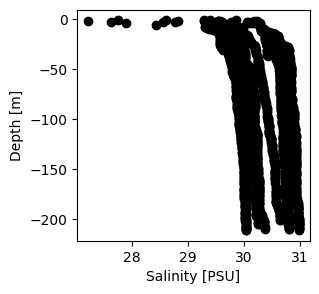

In [166]:
fig, ax = plt.subplots(figsize =(3,3))
plot_depth_profile(ctd_pivot['Salinity'], ax=ax, color='k', label_axes=True)

Plot a few profiles colored by month:

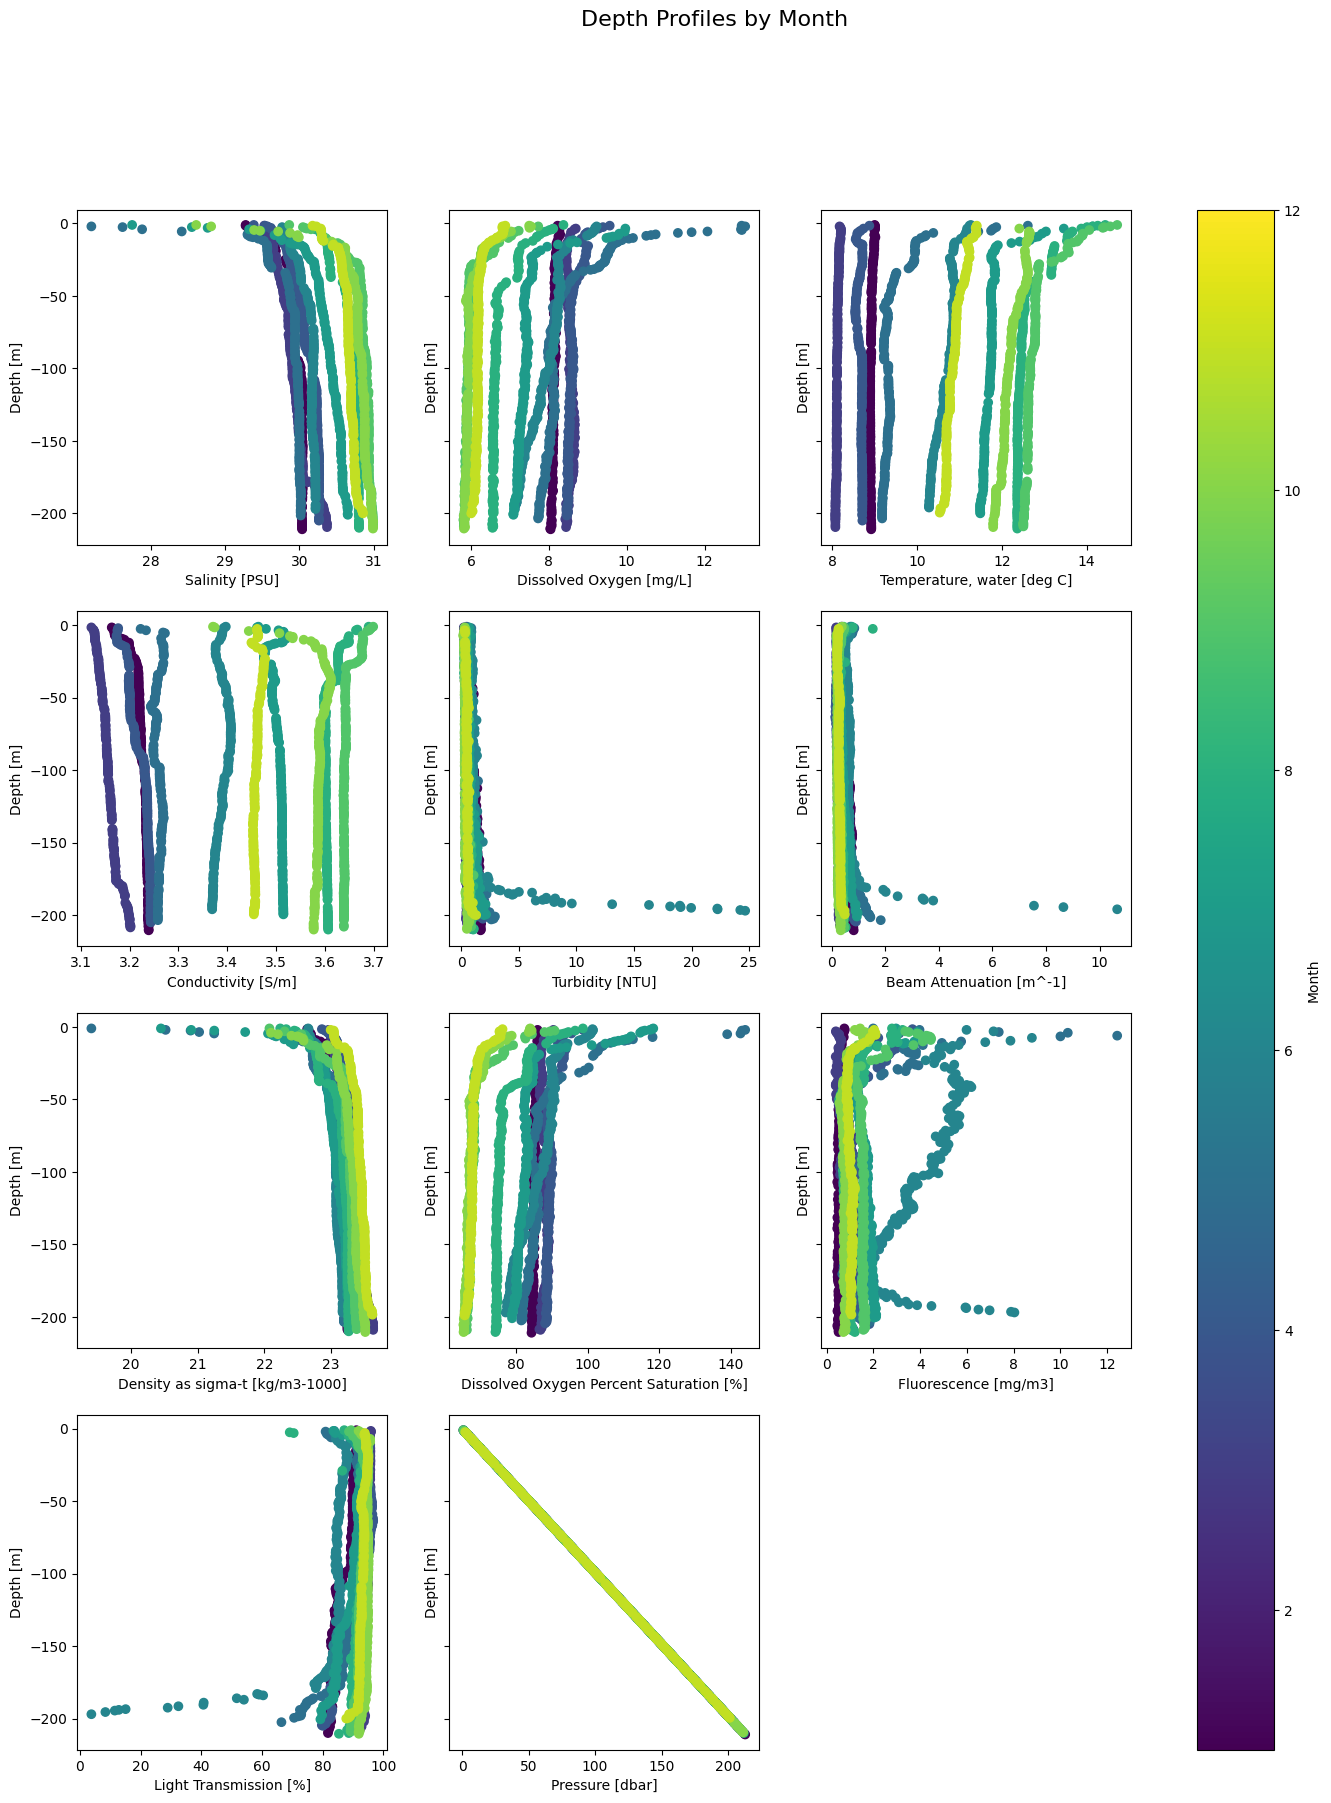

In [175]:
profile_plot_kwargs = dict(
    norm=mpl.colors.Normalize(vmin=1, vmax=12),  # uniform colormap extent
    cmap='viridis',
    label_axes=True,
)

# Create flattened axes array and remove unused ones
fig, ax = plt.subplots(4, 3, figsize=(17, 20), sharey=True, squeeze=False)

# Flatten the axes array for easier indexing
ax_flat = ax.flatten()

# Plot your 13 subplots
sc = plot_depth_profile_by_month(ctd_pivot['Salinity'], ax=ax_flat[0], **profile_plot_kwargs)
sc2 = plot_depth_profile_by_month(ctd_pivot['Dissolved Oxygen'], ax=ax_flat[1], **profile_plot_kwargs)
sc3 = plot_depth_profile_by_month(ctd_pivot['Temperature, water'], ax=ax_flat[2], **profile_plot_kwargs)
sc4 = plot_depth_profile_by_month(ctd_pivot['Conductivity'], ax=ax_flat[3], **profile_plot_kwargs)
sc5 = plot_depth_profile_by_month(ctd_pivot['Turbidity'], ax=ax_flat[4], **profile_plot_kwargs)
sc6 = plot_depth_profile_by_month(ctd_pivot['Beam Attenuation'], ax=ax_flat[5], **profile_plot_kwargs)
sc7 = plot_depth_profile_by_month(ctd_pivot['Density as sigma-t'], ax=ax_flat[6], **profile_plot_kwargs)
sc8 = plot_depth_profile_by_month(ctd_pivot['Dissolved Oxygen Percent Saturation'], ax=ax_flat[7], **profile_plot_kwargs)
sc9 = plot_depth_profile_by_month(ctd_pivot['Fluorescence'], ax=ax_flat[8], **profile_plot_kwargs)
sc10 = plot_depth_profile_by_month(ctd_pivot['Light Transmission'], ax=ax_flat[9], **profile_plot_kwargs)
sc11 = plot_depth_profile_by_month(ctd_pivot['Pressure'], ax=ax_flat[10], **profile_plot_kwargs)
#sc6 = plot_depth_profile_by_month(ctd_pivot['Photosynthetically active radiation'], ax=ax_flat[5], **profile_plot_kwargs)
#sc7 = plot_depth_profile_by_month(ctd_pivot['pH'], ax=ax_flat[6], **profile_plot_kwargs)

# Hide the 2 unused axes (indices 13 and 14)
for unused_ax in ax_flat[11:]:
    fig.delaxes(unused_ax)

cbar = fig.colorbar(sc, ax=ax, label='Month')
fig.suptitle('Depth Profiles by Month', fontsize=16)
plt.tight_layout
fig.savefig('DepthProfiles.png', dpi=200,  bbox_inches='tight')

Example use of the TEOS-10 Gibbs SeaWater (GSW) Oceanographic Toolbox:

In [168]:
ctd_pivot['Salinity_Absolute'] = gsw.SA_from_SP(SP=ctd_pivot["Salinity"], p=ctd_pivot["Pressure"], lon=station_longitude, lat=station_latitude)

# Update units dictionary
parameter_units['Salinity_Absolute'] = 'g/kg'

ctd_pivot

,Result_Parameter_Name,Beam Attenuation,Conductivity,Density as sigma-t,Dissolved Oxygen,Dissolved Oxygen Percent Saturation,Fluorescence,Light Transmission,Photosynthetically active radiation,Pressure,Salinity,"Temperature, water",Turbidity,pH,Salinity_Absolute
Field_Collection_Date_Time,Depth_Value,,,,,,,,,,,,,,
2019-01-11 17:46:22+00:00,1.0,0.3696,NaN,NaN,NaN,NaN,0.751893,91.1745,NaN,1.008,29.2786,9.0017,NaN,NaN,29.420084
2019-01-11 17:46:23+00:00,1.5,NaN,3.163341,22.6404,8.221979,NaN,NaN,91.3480,NaN,NaN,29.2779,9.0066,0.5530,NaN,NaN
2019-01-11 17:46:24+00:00,2.0,0.3660,3.164673,NaN,8.229500,86.00427,0.772533,91.2551,NaN,NaN,NaN,9.0098,NaN,NaN,NaN
2019-01-11 17:46:25+00:00,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.521,NaN,NaN,0.5712,NaN,NaN
2019-01-11 17:46:26+00:00,3.0,NaN,3.167036,NaN,8.256423,NaN,NaN,NaN,NaN,3.025,29.3103,9.0125,NaN,NaN,29.451864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-11-14 20:13:05+00:00,198.0,0.4590,NaN,23.6118,6.025146,NaN,NaN,89.1602,NaN,NaN,NaN,10.5587,0.9378,NaN,NaN
2019-11-14 20:13:06+00:00,198.5,0.4641,3.454463,23.6207,6.039350,NaN,1.056175,89.0459,NaN,200.277,30.8465,NaN,NaN,NaN,30.997814
2019-11-14 20:13:07+00:00,199.0,NaN,NaN,NaN,NaN,65.61294,NaN,88.6022,NaN,200.782,NaN,NaN,NaN,NaN,NaN


C:\Users\Alex Eagan\AppData\Local\Temp\ipykernel_8296\1987419677.py:5: UserWarning: Adding colorbar to a different Figure <Figure size 1700x2200 with 12 Axes> than <Figure size 1000x500 with 3 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(sc, ax=ax, label='Month')


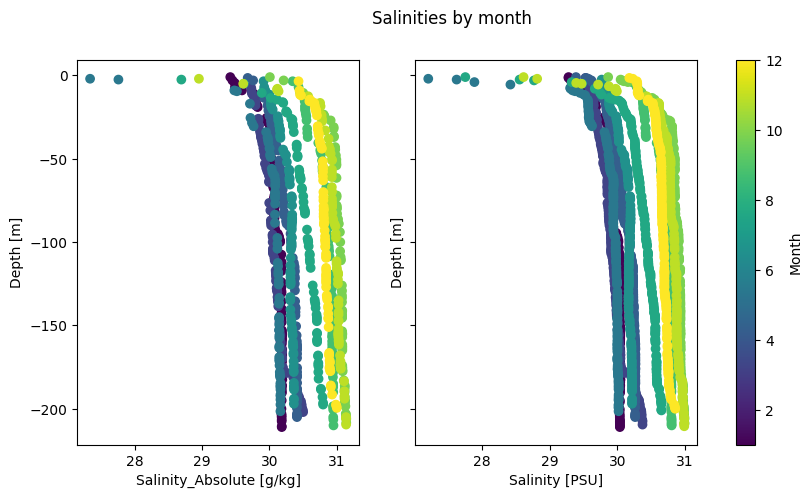

In [169]:
fig, ax = plt.subplots(1,2, figsize =(10,5), sharey=True)
ax1 = plot_depth_profile_by_month(ctd_pivot['Salinity_Absolute'], ax=ax[0])
ax2 =plot_depth_profile_by_month(ctd_pivot['Salinity'], ax=ax[1])

cbar = fig.colorbar(sc, ax=ax, label='Month')
fig.suptitle('Salinities by month')
fig.savefig('Salinities.png', dpi=200,  bbox_inches='tight')

In [170]:


ctd_pivot['RecomputedDensity'] = gsw.rho_t_exact(SA=ctd_pivot["Salinity_Absolute"], t=ctd_pivot["Temperature, water"], p=ctd_pivot["Pressure"])

# Update units dictionary
parameter_units['RecomputedDensity'] = 'kg/m3 -1000'

ctd_pivot

,Result_Parameter_Name,Beam Attenuation,Conductivity,Density as sigma-t,Dissolved Oxygen,Dissolved Oxygen Percent Saturation,Fluorescence,Light Transmission,Photosynthetically active radiation,Pressure,Salinity,"Temperature, water",Turbidity,pH,Salinity_Absolute,RecomputedDensity
Field_Collection_Date_Time,Depth_Value,,,,,,,,,,,,,,,
2019-01-11 17:46:22+00:00,1.0,0.3696,NaN,NaN,NaN,NaN,0.751893,91.1745,NaN,1.008,29.2786,9.0017,NaN,NaN,29.420084,1022.650801
2019-01-11 17:46:23+00:00,1.5,NaN,3.163341,22.6404,8.221979,NaN,NaN,91.3480,NaN,NaN,29.2779,9.0066,0.5530,NaN,NaN,NaN
2019-01-11 17:46:24+00:00,2.0,0.3660,3.164673,NaN,8.229500,86.00427,0.772533,91.2551,NaN,NaN,NaN,9.0098,NaN,NaN,NaN,NaN
2019-01-11 17:46:25+00:00,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.521,NaN,NaN,0.5712,NaN,NaN,NaN
2019-01-11 17:46:26+00:00,3.0,NaN,3.167036,NaN,8.256423,NaN,NaN,NaN,NaN,3.025,29.3103,9.0125,NaN,NaN,29.451864,1022.683180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-11-14 20:13:05+00:00,198.0,0.4590,NaN,23.6118,6.025146,NaN,NaN,89.1602,NaN,NaN,NaN,10.5587,0.9378,NaN,NaN,NaN
2019-11-14 20:13:06+00:00,198.5,0.4641,3.454463,23.6207,6.039350,NaN,1.056175,89.0459,NaN,200.277,30.8465,NaN,NaN,NaN,30.997814,NaN
2019-11-14 20:13:07+00:00,199.0,NaN,NaN,NaN,NaN,65.61294,NaN,88.6022,NaN,200.782,NaN,NaN,NaN,NaN,NaN,NaN


C:\Users\Alex Eagan\AppData\Local\Temp\ipykernel_8296\1415543842.py:7: UserWarning: Adding colorbar to a different Figure <Figure size 1700x2200 with 12 Axes> than <Figure size 1000x500 with 3 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(sc, ax=ax, label='Month')


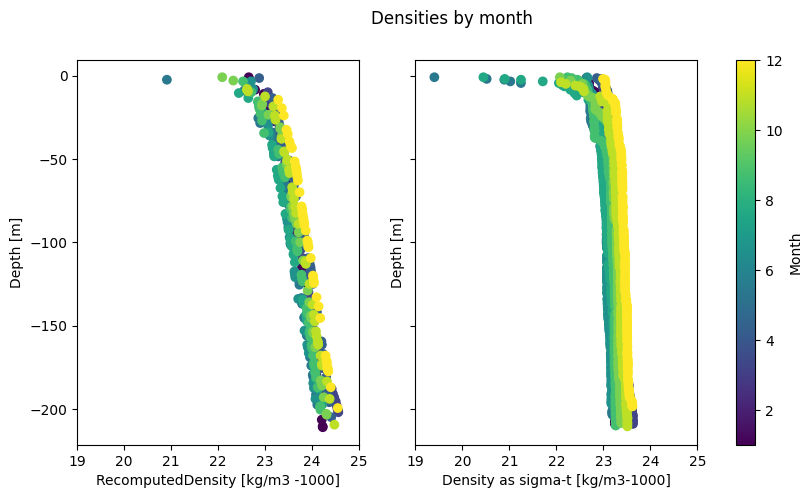

In [171]:
fig, ax = plt.subplots(1,2, figsize =(10,5), sharey=True)
ax1 = plot_depth_profile_by_month(ctd_pivot['RecomputedDensity']-1000, ax=ax[0])
ax[0].set_xlim([19, 25])
ax2 =plot_depth_profile_by_month(ctd_pivot['Density as sigma-t'], ax=ax[1])
ax[1].set_xlim([19, 25])

cbar = fig.colorbar(sc, ax=ax, label='Month')
fig.suptitle('Densities by month')
fig.savefig('RecomputedDensity.png', dpi=200,  bbox_inches='tight')

# No Pivot

This example shows how to use the data without pivoting.

Text(0, 0.5, 'Depth (m)')

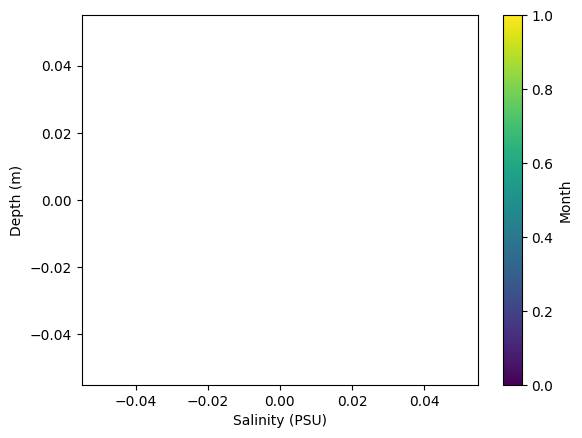

In [172]:
WATER_QUALITY_FILE_PATH = 'C:\\Users\\Alex Eagan\\Downloads\\ajeagan5114788\\EIMContinuousDepthSeriesData_2026Apr10_9938.csv'  # e.g. './data/EIMContinuousDepthSeriesData_2024Apr08_229519.csv'
ctd_all_data = pd.read_csv(WATER_QUALITY_FILE_PATH)

# Convert date strings to datetimes
ctd_all_data['Field_Collection_Date_Time'] = pd.to_datetime(
    ctd_all_data['Field_Collection_Date_Time'],
    format='%m/%d/%Y %I:%M:%S %p',
    utc=True
)

# Define start and end times to filter data.  Update these as needed.
start_datetime = pd.Timestamp('2017-01-01 00:00:00', tz='UTC')
end_datetime = pd.Timestamp('2017-12-31 00:00:00', tz='UTC')

# Only use date time as index (not depth)
ctd_subset = (ctd_all_data
    .set_index('Field_Collection_Date_Time')
    .sort_index()
    .loc[start_datetime:end_datetime]
)

# Filter for salinity data
salinity = ctd_subset[ctd_subset['Result_Parameter_Name'] == 'Salinity']

fig, ax = plt.subplots()
sc = ax.scatter(
    x=salinity['Result_Value'],
    y=-salinity['Depth_Value'],
    c=salinity.index.month,
)
cbar = fig.colorbar(sc, ax=ax, label='Month')
ax.set_xlabel('Salinity (PSU)')
ax.set_ylabel('Depth (m)')